# Visualizaciones - Carencia de servicios básicos en Los Ríos (2017 vs 2024)

Toma `indicadores_vivienda.csv` (generado por el notebook de scraping) y el
shapefile de comunas para construir el gráfico de barras comparativo y los
mapas de calor por comuna.

In [2]:
import unicodedata
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

INDICADORES_CSV = Path("indicadores_vivienda.csv")
SHAPEFILE = Path("Comunas") / "comunas.shp"
BG = "#f7f1e3"
YEARS = [2017, 2024]
INDICADOR = "carencia_servicios_basicos"

df = pd.read_csv(INDICADORES_CSV, encoding="utf-8-sig")
df.head()

,comuna,carencia_servicios_basicos_2017,carencia_servicios_basicos_2024
0,Corral,59.1,52.6
1,Futrono,40.6,37.4
2,La Unión,30.9,27.4
3,Lago Ranco,41.5,34.3
4,Lanco,19.3,20.6


## Gráfico de barras: comparación por comuna entre años

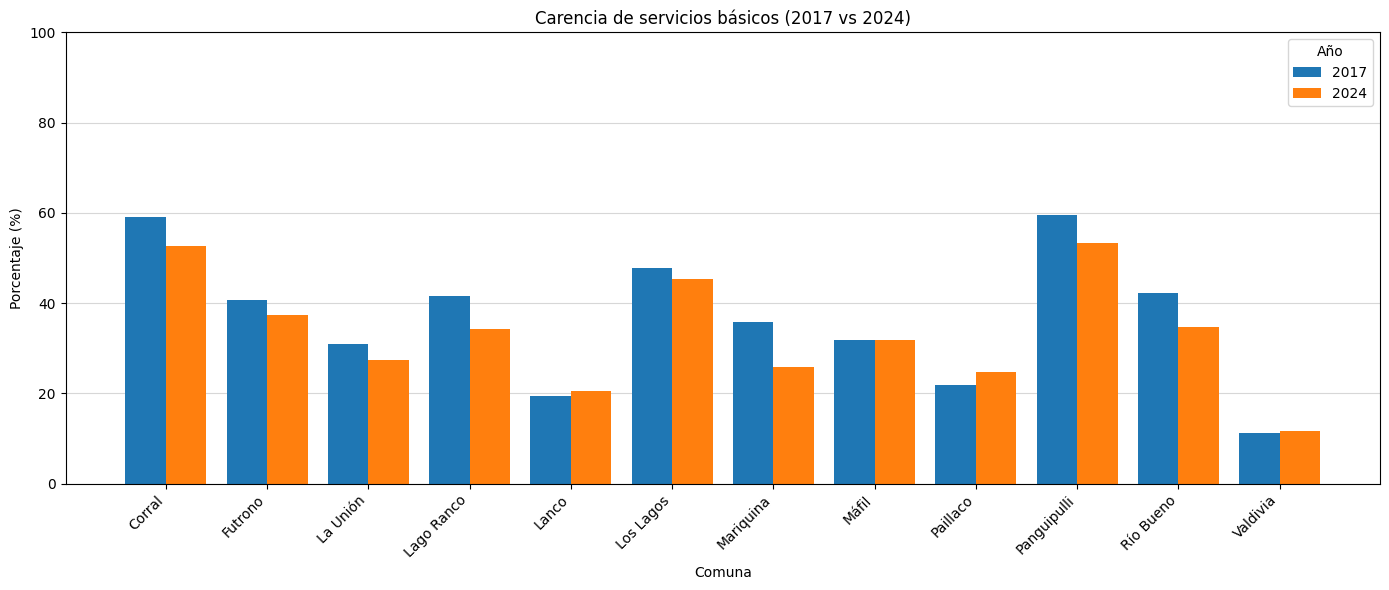

In [3]:
columnas = [col for col in df.columns if col.startswith(f"{INDICADOR}_")]
years_barras = [int(col.rsplit("_", 1)[-1]) for col in columnas]
pivot = df[["comuna"] + columnas].sort_values("comuna").set_index("comuna")

x = range(len(pivot))
width = 0.8 / len(years_barras)

fig, ax = plt.subplots(figsize=(14, 6))
for i, ano in enumerate(years_barras):
    vals = pd.to_numeric(pivot[f"{INDICADOR}_{ano}"], errors="coerce").tolist()
    positions = [xi - 0.4 + i * width + width / 2 for xi in x]
    ax.bar(positions, vals, width, label=str(ano))

ax.set_xticks(list(x))
ax.set_xticklabels(pivot.index.tolist(), rotation=45, ha="right")
ax.set_ylabel("Porcentaje (%)")
ax.set_xlabel("Comuna")
ax.set_title("Carencia de servicios básicos (2017 vs 2024)")
ax.set_ylim(0, 100)
ax.legend(title="Año")
ax.grid(True, axis="y", alpha=0.5)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(f"servicios_basicos_{years_barras[0]}vs{years_barras[-1]}.png", dpi=300, bbox_inches="tight")
plt.show()

## Mapas de calor por comuna

Normalizamos los nombres de comuna(sin tildes, minúsculas, espacios colapsados) 
y nos quedamos con la región 14 (Los Ríos, `codregion == "14" `).

In [4]:
def norm(value):
    text = "" if value is None else str(value)
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    return " ".join(text.lower().split())


gdf = gpd.read_file(SHAPEFILE)
gdf = gdf[gdf["codregion"].astype(str) == "14"].copy()
gdf["key"] = gdf["Comuna"].map(norm)


def etiquetar_comunas(ax, mapa):
    for _, row in mapa.iterrows():
        if row.geometry is None:
            continue
        label = str(row["Comuna"]).strip()
        if label:
            point = row.geometry.representative_point()
            ax.annotate(label, xy=(point.x, point.y), ha="center", fontsize=8)

Cada mapa se grafica con `legend=True` y sin fijar `vmin`/`vmax`, así
geopandas calcula la escala de color a partir del rango propio de ese año en
vez de usar una escala común. El rango de carencia cambia bastante entre 2017
y 2024, y forzar la misma escala aplastaba el contraste dentro de cada mapa.

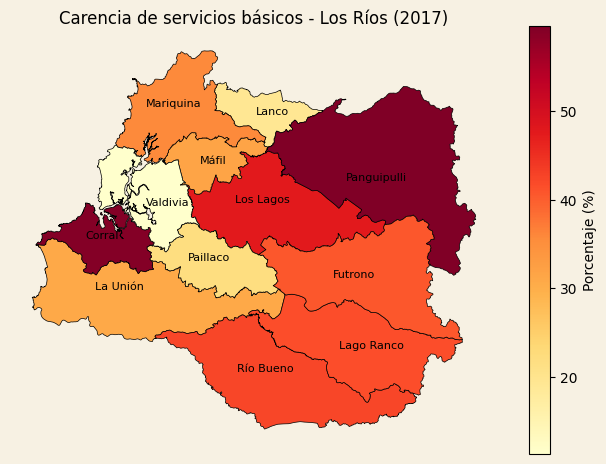

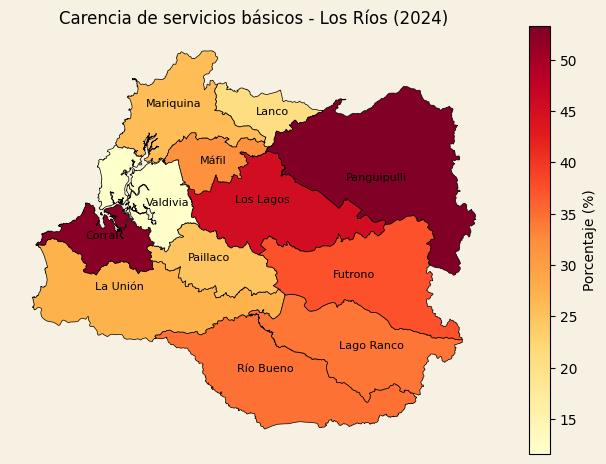

In [5]:
mapas = {}

for year in YEARS:
    df_year = df[["comuna", f"{INDICADOR}_{year}"]].rename(columns={f"{INDICADOR}_{year}": "valor"})
    df_year["key"] = df_year["comuna"].map(norm)

    mapa = gdf.merge(df_year, on="key", how="left")
    mapas[year] = mapa

    ax = mapa.plot(
        column="valor",
        cmap="YlOrRd",
        edgecolor="black",
        linewidth=0.5,
        legend=True,
        legend_kwds={"label": "Porcentaje (%)"},
        missing_kwds={"color": "lightgrey"},
    )
    ax.set_facecolor(BG)
    ax.figure.set_facecolor(BG)
    etiquetar_comunas(ax, mapa)
    ax.set_title(f"Carencia de servicios básicos - Los Ríos ({year})")
    ax.axis("off")
    ax.figure.tight_layout()
    ax.figure.savefig(f"heatmap_{year}.png", dpi=300, bbox_inches="tight")
    plt.show()

## Comparación lado a lado

Misma idea que arriba, pero en una sola figura: cada subplot trae su propia
barra de color normalizada según los valores de ese año, en lugar de compartir
una escala única entre 2017 y 2024.

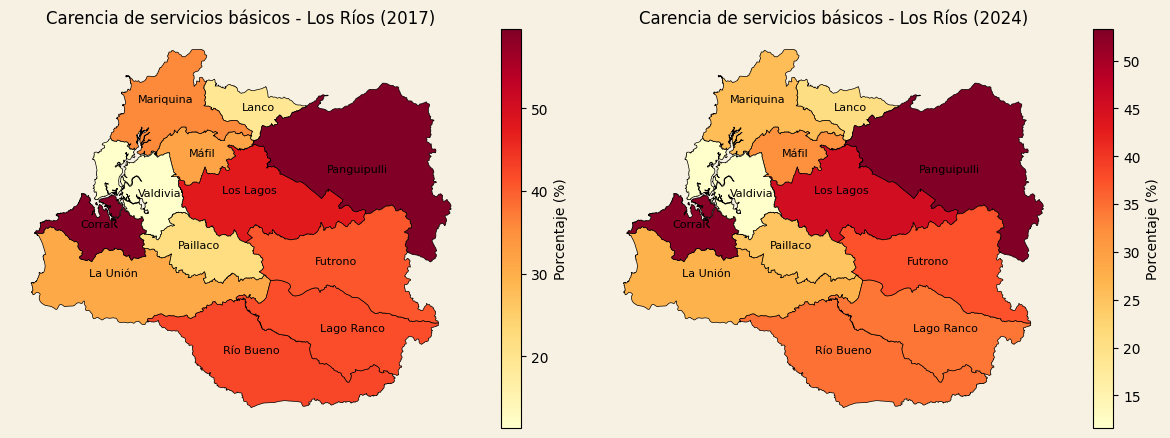

In [6]:
fig, axes = plt.subplots(1, len(YEARS), figsize=(6 * len(YEARS), 6))
fig.patch.set_facecolor(BG)

for ax, year in zip(axes, YEARS):
    mapa = mapas[year]
    mapa.plot(
        column="valor",
        cmap="YlOrRd",
        edgecolor="black",
        linewidth=0.5,
        ax=ax,
        legend=True,
        legend_kwds={"label": "Porcentaje (%)", "shrink": 0.7},
        missing_kwds={"color": "lightgrey"},
    )
    ax.set_facecolor(BG)
    etiquetar_comunas(ax, mapa)
    ax.set_title(f"Carencia de servicios básicos - Los Ríos ({year})")
    ax.axis("off")

fig.tight_layout()
fig.savefig("heatmap_2017_2024.png", dpi=300, bbox_inches="tight")
plt.show()